In [485]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns

In [486]:
df = pd.read_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-11/segmentation_data.csv")
df

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799.0,688.0,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0.0,Port Elizabeth,AS,Cyprus,2.0,2,Low
1,57,Female,Bachelor's,Widowed,NaN,690.0,33835.0,Auto,Employed,6,Fair,0.148920,55849.0,0.0,North Catherine,OH,Turkmenistan,3.0,2,Medium
2,21,Non-binary,Master's,Single,55687.0,600.0,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3.0,South Scott,OK,Luxembourg,3.0,2,Medium
3,59,Male,Bachelor's,Single,26508.0,622.0,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3.0,Robinhaven,PR,Uganda,4.0,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427.0,766.0,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,NaN,New Heather,IL,Namibia,3.0,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,23,Non-binary,Bachelor's,Widowed,48088.0,609.0,26187.0,Home,Self-employed,2,Fair,0.317633,NaN,4.0,Susanstad,TN,Djibouti,2.0,0,Low
14996,56,Male,PhD,Single,107193.0,700.0,35111.0,Auto,Self-employed,10,Fair,0.155126,79102.0,NaN,Port Heather,WA,Congo,0.0,0,Medium
14997,29,Non-binary,PhD,Married,46250.0,642.0,44369.0,Home,Unemployed,19,Excellent,0.593999,196930.0,4.0,South Morganchester,LA,Palau,2.0,1,High
14998,53,Non-binary,PhD,Divorced,40180.0,638.0,32752.0,Home,Self-employed,12,Excellent,0.478035,276060.0,NaN,Port Wayne,AK,Rwanda,0.0,2,High


In [487]:
df.shape

(15000, 20)

In [488]:
df.dtypes[:]

Age                        int64
Gender                       str
Education Level              str
Marital Status               str
Income                   float64
Credit Score             float64
Loan Amount              float64
Loan Purpose                 str
Employment Status            str
Years at Current Job       int64
Payment History              str
Debt-to-Income Ratio     float64
Assets Value             float64
Number of Dependents     float64
City                         str
State                        str
Country                      str
Previous Defaults        float64
Marital Status Change      int64
Risk Rating                  str
dtype: object

# <b>`Preprocessing`

In [489]:
df.isnull().sum()[:]

Age                         0
Gender                      0
Education Level             0
Marital Status              0
Income                   2250
Credit Score             2250
Loan Amount              2250
Loan Purpose                0
Employment Status           0
Years at Current Job        0
Payment History             0
Debt-to-Income Ratio        0
Assets Value             2250
Number of Dependents     2250
City                        0
State                       0
Country                     0
Previous Defaults        2250
Marital Status Change       0
Risk Rating                 0
dtype: int64

In [490]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Age', 'Income', 'Credit Score', 'Loan Amount', 'Years at Current Job',
       'Debt-to-Income Ratio', 'Assets Value', 'Number of Dependents',
       'Previous Defaults', 'Marital Status Change'],
      dtype='str')

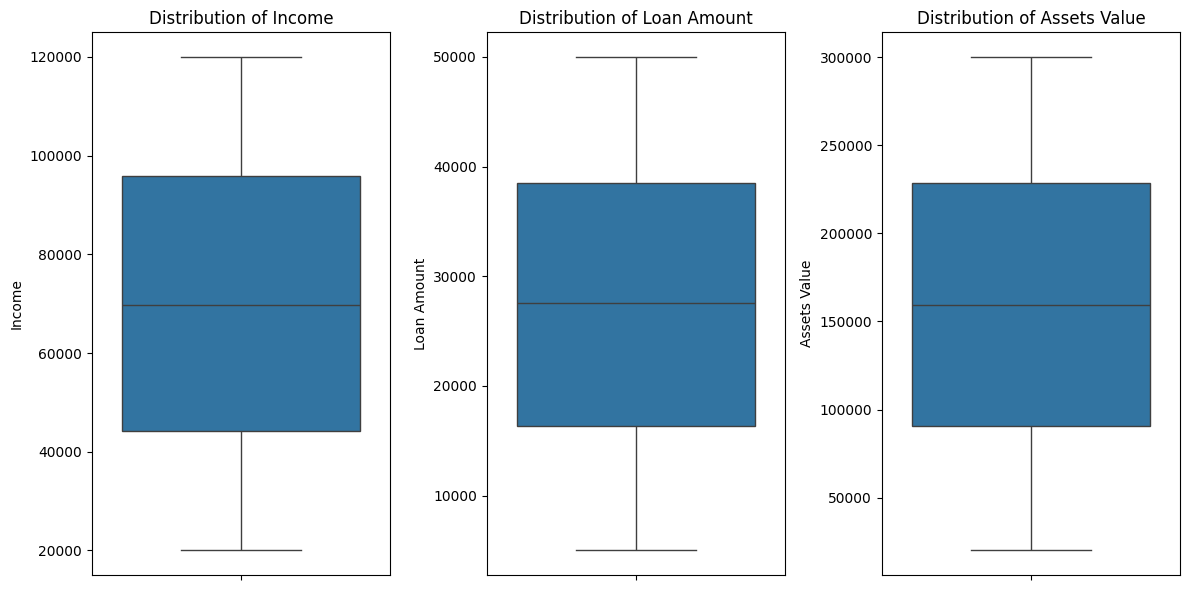

In [491]:
# Income Loan Amount Assets Value                
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Income'])
plt.title('Distribution of Income')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Loan Amount'])
plt.title('Distribution of Loan Amount')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Assets Value'])
plt.title('Distribution of Assets Value')

plt.tight_layout()
plt.show()

In [492]:
col = ['Income', 'Loan Amount', 'Assets Value']
for c in col:
    skew = round(df[c].skew(), 4)
    print(f"Skewness of {c}: {skew}")

Skewness of Income: 0.0104
Skewness of Loan Amount: -0.0014
Skewness of Assets Value: 0.0016


In [493]:
df['Loan Purpose'].value_counts()   

Loan Purpose
Personal    3771
Home        3766
Business    3738
Auto        3725
Name: count, dtype: int64

In [494]:
df_copy = df[~ (df['Income'].isna()) ].copy()

In [495]:
df_copy.isna().sum()

Age                         0
Gender                      0
Education Level             0
Marital Status              0
Income                      0
Credit Score             1916
Loan Amount              1913
Loan Purpose                0
Employment Status           0
Years at Current Job        0
Payment History             0
Debt-to-Income Ratio        0
Assets Value             1921
Number of Dependents     1907
City                        0
State                       0
Country                     0
Previous Defaults        1935
Marital Status Change       0
Risk Rating                 0
dtype: int64

In [496]:
df_copy = df_copy[~df_copy['Credit Score'].isna()]

In [497]:
df_copy = df_copy[~df_copy['Previous Defaults'].isna()]

In [498]:
df_copy.fillna(0.0, inplace=True)

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799.0,688.0,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0.0,Port Elizabeth,AS,Cyprus,2.0,2,Low
2,21,Non-binary,Master's,Single,55687.0,600.0,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3.0,South Scott,OK,Luxembourg,3.0,2,Medium
3,59,Male,Bachelor's,Single,26508.0,622.0,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3.0,Robinhaven,PR,Uganda,4.0,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427.0,766.0,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,0.0,New Heather,IL,Namibia,3.0,1,Low
6,31,Non-binary,Master's,Widowed,45280.0,672.0,6553.0,Personal,Self-employed,1,Good,0.378890,0.0,0.0,West Lindaview,MD,Bouvet Island (Bouvetoya),0.0,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,40,Male,High School,Married,43655.0,614.0,34565.0,Home,Unemployed,11,Poor,0.399901,32179.0,4.0,Curtismouth,IA,Uzbekistan,1.0,1,Low
14995,23,Non-binary,Bachelor's,Widowed,48088.0,609.0,26187.0,Home,Self-employed,2,Fair,0.317633,0.0,4.0,Susanstad,TN,Djibouti,2.0,0,Low
14996,56,Male,PhD,Single,107193.0,700.0,35111.0,Auto,Self-employed,10,Fair,0.155126,79102.0,0.0,Port Heather,WA,Congo,0.0,0,Medium
14997,29,Non-binary,PhD,Married,46250.0,642.0,44369.0,Home,Unemployed,19,Excellent,0.593999,196930.0,4.0,South Morganchester,LA,Palau,2.0,1,High


In [499]:
df_copy.isna().sum()

Age                      0
Gender                   0
Education Level          0
Marital Status           0
Income                   0
Credit Score             0
Loan Amount              0
Loan Purpose             0
Employment Status        0
Years at Current Job     0
Payment History          0
Debt-to-Income Ratio     0
Assets Value             0
Number of Dependents     0
City                     0
State                    0
Country                  0
Previous Defaults        0
Marital Status Change    0
Risk Rating              0
dtype: int64

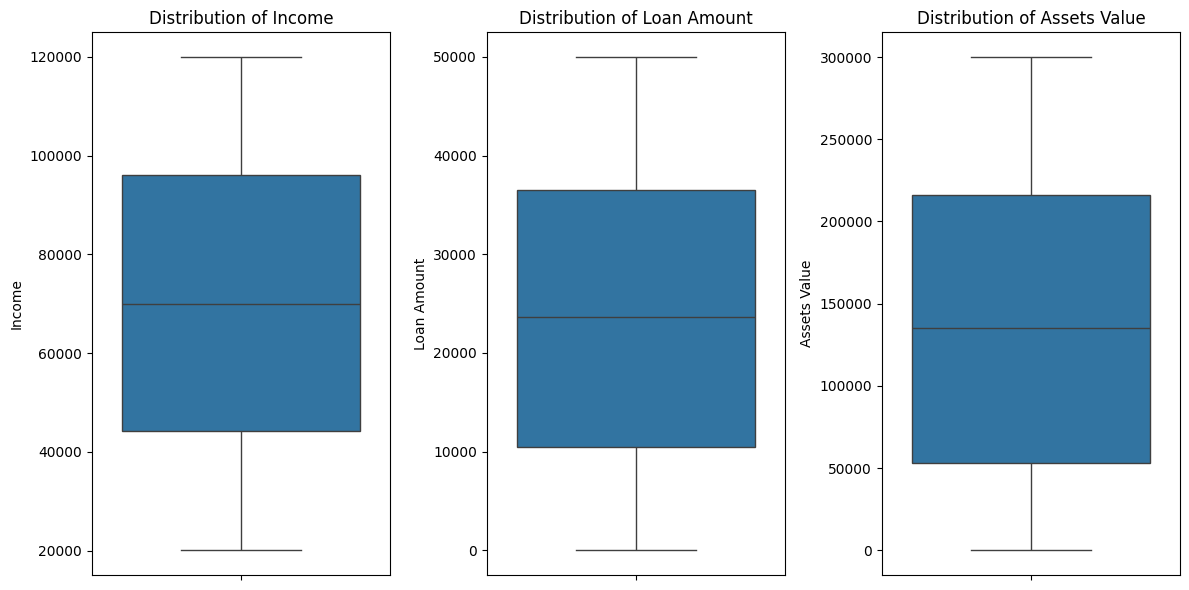

In [500]:
# Income Loan Amount Assets Value                
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_copy['Income'])
plt.title('Distribution of Income')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_copy['Loan Amount'])
plt.title('Distribution of Loan Amount')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_copy['Assets Value'])
plt.title('Distribution of Assets Value')

plt.tight_layout()
plt.show()

In [501]:
df_copy.select_dtypes(include=['float64']).columns.tolist()

['Income',
 'Credit Score',
 'Loan Amount',
 'Debt-to-Income Ratio',
 'Assets Value',
 'Number of Dependents',
 'Previous Defaults']

In [502]:
df_copy['Number of Dependents'] = df_copy['Number of Dependents'].astype('int64', errors='ignore')
df_copy['Previous Defaults'] = df_copy['Previous Defaults'].astype('int64', errors='ignore')
df_copy['Credit Score'] = df_copy['Credit Score'].astype('int64', errors='ignore')

In [503]:
df_copy.head()

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799.0,688,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0,Port Elizabeth,AS,Cyprus,2,2,Low
2,21,Non-binary,Master's,Single,55687.0,600,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3,South Scott,OK,Luxembourg,3,2,Medium
3,59,Male,Bachelor's,Single,26508.0,622,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3,Robinhaven,PR,Uganda,4,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427.0,766,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,0,New Heather,IL,Namibia,3,1,Low
6,31,Non-binary,Master's,Widowed,45280.0,672,6553.0,Personal,Self-employed,1,Good,0.378890,0.0,0,West Lindaview,MD,Bouvet Island (Bouvetoya),0,1,Low


<b> Making a different datset for Model Training

In [504]:
df_model = df_copy.copy()

In [505]:
cols = ['Income', 'Credit Score',
        'Loan Amount', 'Assets Value',
        'Number of Dependents', 'Previous Defaults']

for col in cols:
    df_model[col] = df_model[col].astype('int64', errors='ignore')

df_model['Debt-to-Income Ratio'] = df_model['Debt-to-Income Ratio'].round(2)

In [506]:
df_model.head()

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799,688,45713,Business,Unemployed,19,Poor,0.15,120228,0,Port Elizabeth,AS,Cyprus,2,2,Low
2,21,Non-binary,Master's,Single,55687,600,36623,Home,Employed,8,Fair,0.36,180700,3,South Scott,OK,Luxembourg,3,2,Medium
3,59,Male,Bachelor's,Single,26508,622,26541,Personal,Unemployed,2,Excellent,0.45,157319,3,Robinhaven,PR,Uganda,4,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427,766,36528,Personal,Unemployed,10,Fair,0.14,287140,0,New Heather,IL,Namibia,3,1,Low
6,31,Non-binary,Master's,Widowed,45280,672,6553,Personal,Self-employed,1,Good,0.38,0,0,West Lindaview,MD,Bouvet Island (Bouvetoya),0,1,Low


# <b>`Exploratory Data Analysis`

In [507]:
df_copy.head()

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799.0,688,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0,Port Elizabeth,AS,Cyprus,2,2,Low
2,21,Non-binary,Master's,Single,55687.0,600,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3,South Scott,OK,Luxembourg,3,2,Medium
3,59,Male,Bachelor's,Single,26508.0,622,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3,Robinhaven,PR,Uganda,4,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427.0,766,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,0,New Heather,IL,Namibia,3,1,Low
6,31,Non-binary,Master's,Widowed,45280.0,672,6553.0,Personal,Self-employed,1,Good,0.378890,0.0,0,West Lindaview,MD,Bouvet Island (Bouvetoya),0,1,Low


In [508]:
def RFS1(x):
    r = 1 if (x['Credit Score'] >= 699 and 
              x['Previous Defaults'] < 2 and 
              x['Risk Rating'] == 'Low') else 0

    f = 1 if (x['Income'] > 69933 and 
              x['Assets Value'] > 159742 and 
              x['Loan Amount'] < 27450 and 
              x['Debt-to-Income Ratio'] <= 0.35) else 0

    s = 1 if (x['Years at Current Job'] >= 9 and 
              x['Payment History'] in {'Excellent', 'Good'}) else 0

    return dict_rfm[str(r) + str(f) + str(s)]

dict_rfm = {
    '111': 'High Net-Worth Prime',      # Top-tier clients with strong financial position, stability, and low risk
    '011': 'Premium Watchlist',         # Wealthy, stable but flagged for recent credit/risk events
    '101': 'Volatile Affluent',         # Wealthy, creditworthy but recent instability in income or status
    '001': 'Asset-Heavy Prospect',      # Significant assets, but lacking stability and reliable financial behavior
    '110': 'Growth Stable',             # Reliable/stable client showing potential for strong asset accumulation
    '100': 'Emerging Profile',          # Newly engaged client, recent credit/event, financial potential uncertain
    '010': 'Consistent Moderate',       # Stable but lacking strong financial standing or asset base, some reliability
    '000': 'Low Engagement'             # No strong financial, stability, or credit characteristics; low contributor
}

In [509]:
df_analysis = df_copy.copy()
df_analysis['Label'] = df_analysis.apply(RFS1, axis=1)
df_analysis.head()

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating,Label
0,49,Male,PhD,Divorced,72799.0,688,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0,Port Elizabeth,AS,Cyprus,2,2,Low,Low Engagement
2,21,Non-binary,Master's,Single,55687.0,600,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3,South Scott,OK,Luxembourg,3,2,Medium,Low Engagement
3,59,Male,Bachelor's,Single,26508.0,622,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3,Robinhaven,PR,Uganda,4,2,Medium,Low Engagement
4,25,Non-binary,Bachelor's,Widowed,49427.0,766,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,0,New Heather,IL,Namibia,3,1,Low,Low Engagement
6,31,Non-binary,Master's,Widowed,45280.0,672,6553.0,Personal,Self-employed,1,Good,0.378890,0.0,0,West Lindaview,MD,Bouvet Island (Bouvetoya),0,1,Low,Low Engagement


# <b>`Machine Learning`

## <b>`Preprocessing`

In [510]:
df_model.reset_index(inplace=True)

### `Feature Enginneering`

In [512]:
df_model['Gender'].unique().tolist()

['Male', 'Non-binary', 'Female']

In [513]:
pd.get_dummies(df_model['Gender']).astype('int64').drop(columns=['Non-binary']).head()

,Female,Male
0,0,1
1,0,0
2,0,1
3,0,0
4,0,0


In [514]:
df_model = pd.concat([df_model, pd.get_dummies(df_model['Gender']).astype('int64').drop(columns=['Non-binary'])], axis=1).drop(['Gender'], axis=1)

In [515]:
df_model.drop(['City', 'State', 'Country'], axis=1, inplace=True)

In [516]:
str_cols = df_model.select_dtypes(include=['str']).columns.tolist()

In [517]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [518]:
df_dummy = pd.DataFrame()

In [519]:
for col in str_cols:
    df_dummy[f'{col}_encoded'] = le.fit_transform(df_model[col])

In [521]:
df_model = pd.concat([df_model, df_dummy], axis=1)

In [524]:
df_model.drop(columns=str_cols, inplace=True)

In [525]:
df_model

,index,Age,Income,Credit Score,Loan Amount,Years at Current Job,Debt-to-Income Ratio,Assets Value,Number of Dependents,Previous Defaults,Marital Status Change,Female,Male,Education Level_encoded,Marital Status_encoded,Loan Purpose_encoded,Employment Status_encoded,Payment History_encoded,Risk Rating_encoded
0,0,49,72799,688,45713,19,0.15,120228,0,2,2,0,1,3,0,1,2,3,1
1,2,21,55687,600,36623,8,0.36,180700,3,3,2,0,0,2,2,2,0,1,2
2,3,59,26508,622,26541,2,0.45,157319,3,4,2,0,1,0,2,3,2,0,2
3,4,25,49427,766,36528,10,0.14,287140,0,3,1,0,0,0,3,3,2,1,1
4,6,31,45280,672,6553,1,0.38,0,0,0,1,0,0,2,3,3,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9180,14994,40,43655,614,34565,11,0.40,32179,4,1,1,0,1,1,1,2,2,3,1
9181,14995,23,48088,609,26187,2,0.32,0,4,2,0,0,0,0,3,2,1,1,1
9182,14996,56,107193,700,35111,10,0.16,79102,0,0,0,0,1,3,2,0,1,1,2
9183,14997,29,46250,642,44369,19,0.59,196930,4,2,1,0,0,3,1,2,2,0,0


### `Model Training`

In [526]:
df_model

,index,Age,Income,Credit Score,Loan Amount,Years at Current Job,Debt-to-Income Ratio,Assets Value,Number of Dependents,Previous Defaults,Marital Status Change,Female,Male,Education Level_encoded,Marital Status_encoded,Loan Purpose_encoded,Employment Status_encoded,Payment History_encoded,Risk Rating_encoded
0,0,49,72799,688,45713,19,0.15,120228,0,2,2,0,1,3,0,1,2,3,1
1,2,21,55687,600,36623,8,0.36,180700,3,3,2,0,0,2,2,2,0,1,2
2,3,59,26508,622,26541,2,0.45,157319,3,4,2,0,1,0,2,3,2,0,2
3,4,25,49427,766,36528,10,0.14,287140,0,3,1,0,0,0,3,3,2,1,1
4,6,31,45280,672,6553,1,0.38,0,0,0,1,0,0,2,3,3,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9180,14994,40,43655,614,34565,11,0.40,32179,4,1,1,0,1,1,1,2,2,3,1
9181,14995,23,48088,609,26187,2,0.32,0,4,2,0,0,0,0,3,2,1,1,1
9182,14996,56,107193,700,35111,10,0.16,79102,0,0,0,0,1,3,2,0,1,1,2
9183,14997,29,46250,642,44369,19,0.59,196930,4,2,1,0,0,3,1,2,2,0,0
